# Determining Ideal Simulation Size

## Imports and constants

In [1]:
import numpy as np
from astropy import units as u, constants as c
from matplotlib import pyplot as plt

import sys
sys.path.append("..")
from oskareor.skalow_calc import SKAMath as omath, EoRCosmology as Cosmo

In [2]:
STATION_DIAMETER = 38 * u.m

cosmo = Cosmo()

print(cosmo.dz_to_z(cosmo.z_to_dz(12.0) - 1024 * u.Mpc))
print(cosmo.dz_to_z(cosmo.z_to_dz(6.0) + 1024 * u.Mpc))

6.203901676789112
11.510524050424577


## Calculating the SKA primary beam size

For the airy disk we will use the calculation for the first minimum, as that is where we can ensure the primary beam edges fully obscure any corner or side-of-box data.

In [3]:
# Create array of redshift values from 5 to 12 inclusive, use 71 entries (i.e. a redshift step of 0.1)
zs = np.linspace(5, 14, 71)

# Frequencies and wavelengths
fs = omath.FREQ_21CM / (zs + 1)
λs = c.c / fs

# Airy disk first minimum
θs = np.asin(1.22 * λs / STATION_DIAMETER).to(u.deg)

print(θs)

[2.33011909 2.38007865 2.43004002 2.48000324 2.52996835 2.57993539
 2.62990438 2.67987538 2.72984842 2.77982354 2.82980077 2.87978016
 2.92976174 2.97974555 3.02973164 3.07972003 3.12971077 3.17970389
 3.22969944 3.27969745 3.32969795 3.379701   3.42970663 3.47971487
 3.52972576 3.57973935 3.62975567 3.67977476 3.72979665 3.7798214
 3.82984903 3.87987958 3.9299131  3.97994962 4.02998918 4.08003181
 4.13007757 4.18012648 4.23017859 4.28023393 4.33029255 4.38035448
 4.43041976 4.48048843 4.53056052 4.58063609 4.63071516 4.68079778
 4.73088398 4.7809738  4.83106729 4.88116448 4.93126541 4.98137012
 5.03147865 5.08159104 5.13170733 5.18182755 5.23195175 5.28207997
 5.33221224 5.38234861 5.43248911 5.48263378 5.53278266 5.5829358
 5.63309323 5.68325499 5.73342112 5.78359166 5.83376665] deg


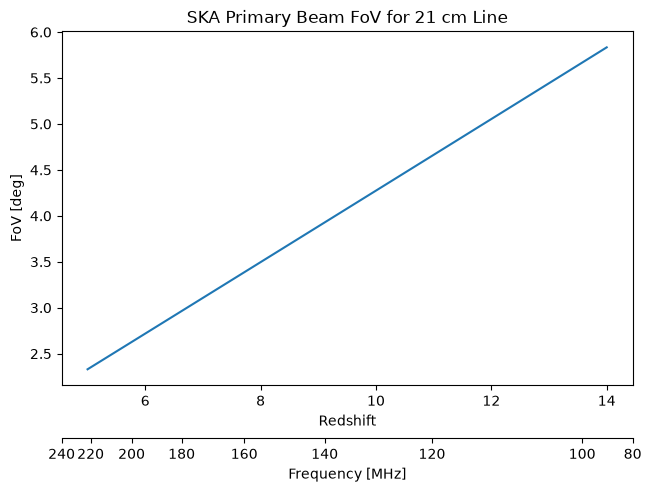

In [4]:
fig, ax = plt.subplots(layout='constrained')

ax.plot(zs, θs)
ax.set_xlabel("Redshift")
ax.set_ylabel("FoV [deg]")
ax.set_title("SKA Primary Beam FoV for 21 cm Line")

# Create a unitless array
fs_mhz = fs.to_value(u.MHz)

z2f = lambda z: np.interp(z, zs, fs_mhz)

f2z = lambda f: np.interp(f, fs_mhz[::-1], zs[::-1])

secax = ax.secondary_xaxis(-0.15, functions=(z2f, f2z))
secax.set_xlabel("Frequency [MHz]")

plt.show()

## Defining Cosmology

Next we need to set the cosmology of the universe so that we can analyse the primary beam in-terms of comoving distance. This will use the already-existing cosmology object that I have made for the reformatter. This uses $H_0=100h, h=0.68$.

In [5]:
cosmo = Cosmo() # Planck survey parameters w/ H0 = 100

print(cosmo.cosmo)

FlatLambdaCDM(H0=100.0 km / (Mpc s), Om0=0.31, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.048)


We can thus, for example, calculate the relationship between redshift, frequency and comoving distance:

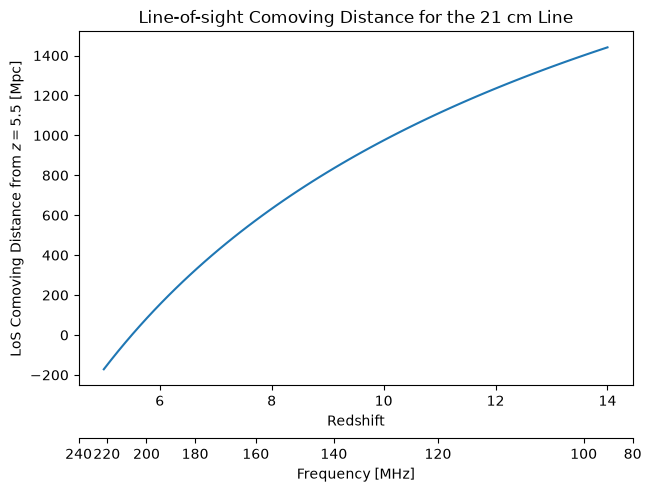

In [6]:
ds = cosmo.z_to_dz(zs)

d_ref = cosmo.z_to_dz(5.5)

fig, ax = plt.subplots(layout='constrained')

ax.plot(zs, ds - d_ref)
ax.set_xlabel("Redshift")
ax.set_ylabel("LoS Comoving Distance from $z = 5.5$ [Mpc]")
ax.set_title("Line-of-sight Comoving Distance for the 21 cm Line")

# Create a unitless array
fs_mhz = fs.to_value(u.MHz)

z2f = lambda z: np.interp(z, zs, fs_mhz)
f2z = lambda f: np.interp(f, fs_mhz[::-1], zs[::-1])

secax = ax.secondary_xaxis(-0.15, functions=(z2f, f2z))
secax.set_xlabel("Frequency [MHz]")

plt.show()

I'm using z = 5.5 as the ideal start point as it might be unnecessary looking at the EoR below such a value, even given a late start to the EoR.

## Getting the Primary Beam in cMpc

Next we can simply apply the calculation built into the cosmology class to get the primary beam size in units of comoving distance. This is calculated using the modified arc length formula $s=r\tan{\theta}$.

In [7]:
ds = np.tan(θs.to(u.rad)) * cosmo.z_to_dz(zs)

print(ds)

[219.08262242 225.70264818 232.34369685 239.00513381 245.68635945
 252.38680652 259.10593772 265.84324359 272.59824051 279.37046892
 286.15949174 292.96489286 299.78627578 306.62326238 313.47549177
 320.34261925 327.22431535 334.1202649  341.03016626 347.95373049
 354.89068071 361.8407514  368.80368778 375.77924529 382.767189
 389.76729316 396.77934074 403.80312294 410.83843885 417.88509505
 424.94290524 432.01168993 439.09127611 446.18149695 453.28219154
 460.39320462 467.51438633 474.64559199 481.78668186 488.93752094
 496.09797879 503.26792933 510.44725064 517.63582485 524.83353793
 532.04027955 539.25594297 546.48042487 553.71362521 560.95544717
 568.20579694 575.46458371 582.73171947 590.007119   597.29069968
 604.58238147 611.88208679 619.18974045 626.50526956 633.82860344
 641.15967359 648.49841356 655.84475894 663.19864726 670.56001795
 677.92881225 685.30497318 692.68844549 700.07917558 707.47711148
 714.88220277] Mpc


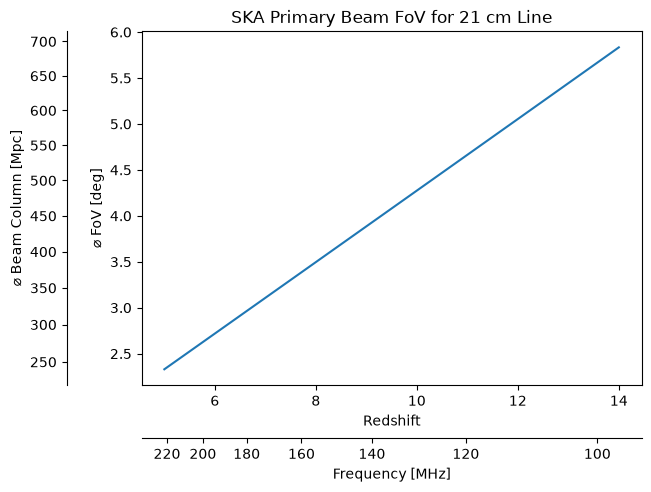

In [8]:
def plot_on_four_axes(zs, θs, fs, ds, f_ticks = 20, d_ticks = 50):
    fig, ax = plt.subplots(layout='constrained')

    ax.plot(zs, θs)
    ax.set_xlabel("Redshift")
    ax.set_ylabel("⌀ FoV [deg]")
    ax.set_title("SKA Primary Beam FoV for 21 cm Line")

    fs_mhz = fs.to_value(u.MHz)

    z2f = lambda z: np.interp(z, zs, fs_mhz)
    f2z = lambda f: np.interp(f, fs_mhz[::-1], zs[::-1])

    secax = ax.secondary_xaxis(-0.15, functions=(z2f, f2z))
    secax.set_xlabel("Frequency [MHz]")
    secax.set_xticks(np.arange(np.trunc(1 + fs_mhz[-1] / f_ticks) * f_ticks, fs_mhz[0], f_ticks))

    θs_deg = θs.to_value(u.deg)
    ds_mpc = ds.to_value(u.Mpc)

    θ2d = lambda θ: np.interp(θ, θs_deg, ds_mpc)
    d2θ = lambda d: np.interp(d, ds_mpc, θs_deg)

    terax = ax.secondary_yaxis(-0.15, functions=(θ2d, d2θ))
    terax.set_ylabel("⌀ Beam Column [Mpc]")
    terax.set_yticks(np.arange(np.trunc(1 + ds_mpc[0] / d_ticks) * d_ticks, ds_mpc[-1], d_ticks))

    return fig, ax, secax, terax

_ = plot_on_four_axes(zs, θs, fs, ds)

plt.show()

## Comparing with simulation boxes

We will consider in all cases that any simulation box produced by `21cmFast` are 1 Mpc across, all that would mean is the number of voxels per side can be reduced by a factor of 2 if needed, as the maximum we can do is voxels 2 Mpc on a side.

From this we consider box sizes that have some multiple of 256 voxels per side. Additionally, the Meraxes coeval box was 600 Mpc across with 1.5 Mpc voxels — this will be used as a sanity check to assure the calculated primary beam is of a reasonable size.

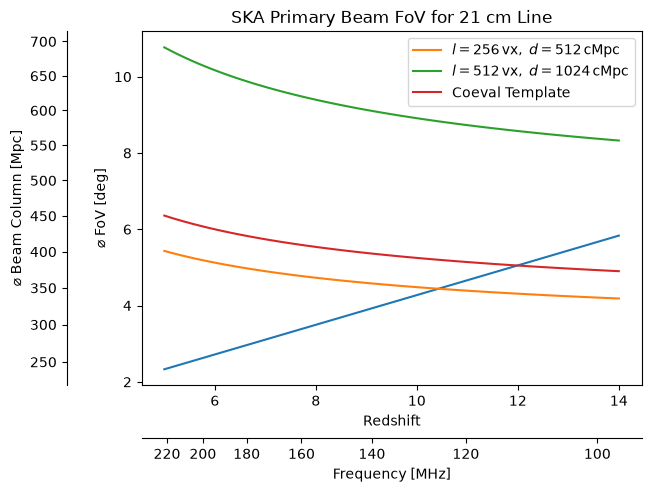

In [18]:
vl = 2 * u.Mpc

def get_sizes(zs, n, vox_len = 1 * u.Mpc):
    # Calculate side length of box
    side = n * vox_len
    
    # From side length we can calculate the subtended angle
    return np.atan(side / cosmo.z_to_dz(zs)).to(u.deg)

ns = np.arange(1, 3, 1) * 256

fig, ax, _, _ = plot_on_four_axes(zs, θs, fs, ds)

# Non-Meraxes Boxes
for n in ns:
    ax.plot(zs, get_sizes(zs, n, vl), label = "$l=%d\,\mathrm{vx},\;d=%d\,\mathrm{cMpc}$" % (n, (n * vl).to_value(u.Mpc)))

# Meraxes Boxes
ax.plot(zs, get_sizes(zs, 400, 1.5 * u.Mpc), label = "Coeval Template")

plt.legend()
plt.show()

As it appears, a 768 cubed box with side length of 768 cMpc is able to stay above the primary beam size for all redshifts. If we used 1.5 cMpc for each voxel the equivalent side length would correspond to a 512 cubed box.

Now reminder that, for the coeval template, at the lowest frequency (125 MHz), the *corners* of the box was *barely* obscured by the primary beam. However, in this graph, the coeval box *edges* should be decently obscured by the beam:

![box](./Screenshot%20from%202026-08-04%2019-58-58.png)

But from the graph above, it is at almost exactly 600 Mpc that the box edges should be fully obscured by the primary beam.

So the next step is to scale the primary beam size to make it fit the data. There are two scaling factors to consider:
- Since only the edges were being obscured, the primary beam has to be at least a factor of $\sqrt{2}$ larger
- The 512 cMpc box seems to have its intersection point at a more correct location — that being a bit above z = 10; i.e. a factor of $600/512\approx1.17$
- To be safe, I am going to multiply by the Airy disk multiplication parameter 1.22 again (to account for how the box was 'barely obscured')

These factors would combine to produce a scaling factor of $1.41 \times 1.17 \times 1.22 \approx 2$. Which means that we *must* use a box of at least 1.2 Gpc in side length

And so by rough estimation if we want to get box that both minimises the length, the easiest path-of-least-resistance is thus using a box where the voxels are 2 cMpc to a side, 600 voxels to a side, and 1.2 Gpc overall to a side.

$\therefore$ the best we can do is $600\times 600\times 600$ which conveniently aligns with covering the entire redshift range from $5.5\geq z \geq 12$.

## OSKAR Simulation Overtime

We can also calculate the amount of time it would take for OSKAR to simulate. It is still likely that OSKAR is the slowest of all the simulation steps. This is using half the value of the formula calculated from the speed simulations:

$\Theta\left(0.0255{(xy)}^{0.8950}{z}^{1.0152}\right)\approx\Theta\left(k^{2.8052}\right)\equiv\Theta\left(n^{0.9351}\right)$

In [10]:
t = 0.0255 * (600 ** 2.8052) * 0.5 * u.second

hrs = t.to_value(u.hr) % 24
mns = (hrs * 60) % 60
scs = (mns * 60) % 60

print("Time to run OSKAR (approx.):")
print("%d days, %d hours, %d minutes, and %.2f seconds; or" % (t.to_value(u.d), hrs, mns, scs))
print("%d hours; or" % (t.to_value(u.hr)))
print("%.2f seconds" % (t.to_value(u.s)))

Time to run OSKAR (approx.):
9 days, 4 hours, 1 minutes, and 40.11 seconds; or
220 hours; or
792100.11 seconds


This is not that bad all things considered. It would mean each simulation would take at most 2 weeks elapsed to complete. Considering that each simulation provides enough data for *multiple* power spectra observations (using 50 channels per would imply 12 power spectra per).